> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib


In [ ]:
# 中文字体：运行环境通常没有 CJK 字体，注册随仓库分发的思源黑体子集
import os, urllib.request, matplotlib, matplotlib.font_manager as fm
FONT = 'NotoSansCJKsc-Regular-subset.otf'
CAND = [FONT, os.path.join('..', 'assets', FONT), os.path.join('..', '..', 'assets', FONT),
        os.path.join('assets', FONT)]
URLS = [
    'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/assets/' + FONT,
    'https://gitee.com/tztgracious/copt-colab-cases/raw/main/assets/' + FONT,
]
path = next((p for p in CAND if os.path.exists(p)), None)
if path is None:
    for u in URLS:
        try:
            urllib.request.urlretrieve(u, FONT); path = FONT; break
        except Exception:
            continue
if path:
    fm.fontManager.addfont(path)
    matplotlib.rcParams['font.sans-serif'] = [fm.FontProperties(fname=path).get_name()]
    matplotlib.rcParams['axes.unicode_minus'] = False
    print('中文字体已就绪:', matplotlib.rcParams['font.sans-serif'][0])
else:
    print('未能加载中文字体，图表中的中文可能显示为方块')

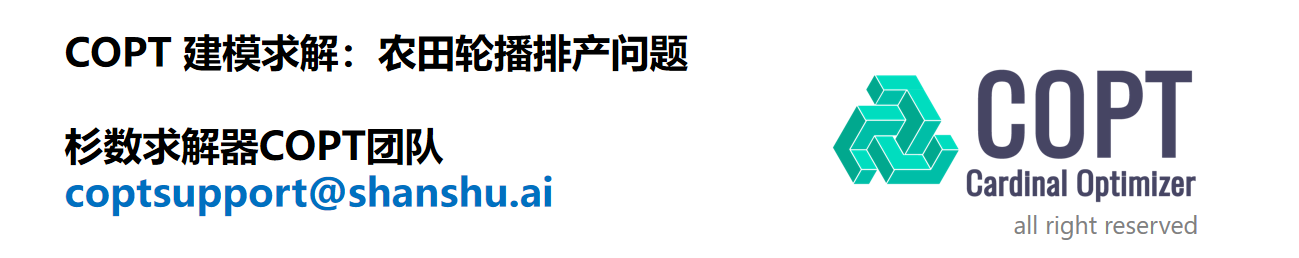

# 农田轮播排产问题代码实现
## 使用COPT建模求解轮播排产问题的步骤

1. **导入COPT-Python接口库** `coptpy`

2. **导入数据**
    - 导入数据（包括土地占用情况、劳动力、水资源需求等）

3. **创建COPT求解环境与模型**

4. **构建模型：依次添加三要素**
    - **决策变量**：添加五个连续型变量：
        - $x_c$：种植作物 $c$ 的公顷数（公顷）
        - $V^P$：雇佣的长期劳动者数量（人）
        - $V_t^T$：第 $t$ 个月雇佣的短期劳动者小时数（小时）
        - $s_c$：第 $c$ 种作物售出量（吨）
        - $z_b$：第 $b$ 中食物组合方案所占比例
    - **目标函数**：在满足约束的条件下最大化全年度的总收益
    - **约束条件**：
        - 土地资源需求
        - 劳动力需求
        - 水资源需求
        - 家庭消耗需求

5. **求解**

6. 查看、分析**结果**

## 导入COPT-Python接口库

In [4]:
import coptpy as cp
from coptpy import COPT

import matplotlib.pyplot as plt

## 添加模型数据

In [6]:
# 导入各种作物按月对土地占用时间比例
crops_land = [[1,    1,    1,    0,    0,    0],
              [1,    1,    1,    0,    0,    0],
              [1,    1,    1,    0.5,  0,    0],
              [1,    1,    1,    1,    0,    0],
              [1,    0,    0.25, 1,    0.25, 0],
              [0,    0,    0,    1,    1,    0],
              [0,    0,    0,    1,    1,    0.75],
              [0,    0,    0,    1,    1,    1],
              [0,    0,    0,    1,    1,    1],
              [0,    0,    0,    1,    0.5,  1],
              [0,  0.25, 0.5,  0.75, 0,    0.75],
              [1,    1,    1,    0,    0,    0]]

# 导入可用土地面积
L = 10

# 导入各种作物每个月所需工时数
crops_labor = [[14,  6,   41,  0,   0,   0],
               [4,   6,   40,  0,   0,   0],
               [8,   6,   40,  40,  0,   0],
               [8,   128, 155, 40,  0,   0],
               [137, 0,   19,  72,  34,  0],
               [0,   0,   0,   16,  40,  0],
               [0,   0,   0,   12,  57,  136],
               [0,   0,   0,   16,  64,  120],
               [0,   0,   0,   8,   35,  96],
               [0,   0,   0,   46,  9,   56],
               [19,  60,  89,  34,  0,   48],
               [11,  6,   37,  0,   0,   0]]

# 导入每个月每个工人最多工时数
labors = [160, 160, 184, 176, 168, 176, 176, 176, 176, 168, 176, 176]

# 导入各种作物每个月所需水量
crops_water = [[0.535, 0.438, 0.452, 0,     0,     0],
               [0.802, 0.479, 0.507, 0,     0,     0],
               [0.556, 0.505, 0.640, 0.197, 0,     0],
               [0.059, 0.142, 0.453, 0.494, 0,     0],
               [0,     0,     0,     1.047, 0.303, 0],
               [0,     0,     0,     1.064, 0.896, 0],
               [0,     0,     0,     1.236, 1.318, 0.120],
               [0,     0,     0,     0.722, 0.953, 0.241],
               [0,     0,     0,     0.089, 0.205, 0.525],
               [0,     0,     0,     0,     0,     0.881],
               [0.373, 0.272, 0,     0,     0,     0.865],
               [0.456, 0.335, 0.305, 0,     0,     0]]

# 导入食物组合
bundles = [[0, 1.20, 0, 0, 0.15, 0.25],
           [0, 0.73, 0, 0, 1.50, 0.25],
           [0, 0.70, 0, 0, 1.00, 0.75]]

# 导入作物产量
crops_yield = [1.50, 1.00, 6.00, 1.50, 1.75, 6.00]

# 导入作物价格
crops_price = [1000, 2000, 750, 3500, 700, 800]

# 导入家庭劳动者数量
V_F = 1.5

# 导入三种劳动者工资
r_F = 4144
r_P = 5180
r_T = 4

# 导入年水资源用量
W = 50

# 导入月水资源用量
w_t = 5

# 导入水费
p_W = 10

# 获取作物种类数量
num_crops = len(crops_land[0])

# 获取食物组合种类
num_bundle = len(bundles)

## 数据预处理

首先，我们对 ``crops_land`` 进行变换，拆分得到48个种植周期的土地占用情况数据表。

In [8]:
crops_land_trans = [[] for _ in range(48)]
for i in range(12):
    for j in  range(num_crops):
        if crops_land[i][j] == int(crops_land[i][j]):
            for k in range(4):
                crops_land_trans[i * 4 + k].append(crops_land[i][j])
        elif crops_land[i][j] == 0.25:
            if crops_land[i - 1][j] == 1:
                crops_land_trans[i * 4].append(1)
                crops_land_trans[i * 4 + 1].append(0)
                crops_land_trans[i * 4 + 2].append(0)
                crops_land_trans[i * 4 + 3].append(0)
            else:
                crops_land_trans[i * 4].append(0)
                crops_land_trans[i * 4 + 1].append(0)
                crops_land_trans[i * 4 + 2].append(0)
                crops_land_trans[i * 4 + 3].append(1)
        elif crops_land[i][j] == 0.5:
            if crops_land[i - 1][j] == 1:
                crops_land_trans[i * 4].append(1)
                crops_land_trans[i * 4 + 1].append(1)
                crops_land_trans[i * 4 + 2].append(0)
                crops_land_trans[i * 4 + 3].append(0)
            else:
                crops_land_trans[i * 4].append(0)
                crops_land_trans[i * 4 + 1].append(0)
                crops_land_trans[i * 4 + 2].append(1)
                crops_land_trans[i * 4 + 3].append(1)
        elif crops_land[i][j] == 0.75:
            if crops_land[i - 1][j] == 1:
                crops_land_trans[i * 4].append(1)
                crops_land_trans[i * 4 + 1].append(1)
                crops_land_trans[i * 4 + 2].append(1)
                crops_land_trans[i * 4 + 3].append(0)
            else:
                crops_land_trans[i * 4].append(0)
                crops_land_trans[i * 4 + 1].append(1)
                crops_land_trans[i * 4 + 2].append(1)
                crops_land_trans[i * 4 + 3].append(1)
display(crops_land_trans)

[[1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 1, 0, 0],
 [1, 1, 1, 1, 0, 0],
 [1, 1, 1, 1, 0, 0],
 [1, 1, 1, 1, 0, 0],
 [1, 1, 1, 1, 0, 0],
 [1, 1, 1, 1, 0, 0],
 [1, 0, 1, 1, 0, 0],
 [1, 0, 0, 1, 0, 0],
 [1, 0, 0, 1, 0, 0],
 [1, 0, 0, 1, 1, 0],
 [0, 0, 0, 1, 1, 0],
 [0, 0, 0, 1, 1, 0],
 [0, 0, 0, 1, 1, 0],
 [0, 0, 0, 1, 1, 0],
 [0, 0, 0, 1, 1, 0],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 0, 1],
 [0, 0, 0, 1, 0, 1],
 [0, 0, 0, 1, 0, 1],
 [0, 0, 0, 1, 0, 1],
 [0, 0, 1, 1, 0, 1],
 [0, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0,

## 创建求解环境和求解模型

In [10]:
env = cp.Envr()
model = env.createModel()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素

### 添加决策变量
- $x_c$：种植作物 $c$ 的公顷数（公顷）
- $V^P$：雇佣的长期劳动者数量（人）
- $V_t^T$：第 $t$ 个月雇佣的短期劳动者小时数（小时）
- $s_c$：第 $c$ 种作物售出量
- $z_b$：第 $b$ 中食物组合方案所占比例
> 以上决策变量均为非负连续变量（劳动者数量可以为小数视为均值）

In [12]:
crops = model.addVars(num_crops, lb=0, nameprefix='crop')
V_P = model.addVar(lb=0, name='V_P')
V_T = model.addVars(12, lb=0, nameprefix='V_T')
sales = model.addVars(num_crops, lb=0, nameprefix='sales')
z_b = model.addVars(num_bundle, lb=0, nameprefix='z_b')

### 设置目标函数
1. 农作物售出收入
$$
    INP = \sum_c p_c \cdot s_c
$$


In [14]:
INP = cp.quicksum(crops_price[i] * sales[i] for i in range(num_crops))

2. 雇佣劳动者支出
    - 家庭劳动者
    $$
        OP_{labor_1} = r^F \cdot V^F
    $$
    - 长期劳动者
    $$
        OP_{labor_2} = r^P \cdot V^P
    $$
    - 短期劳动者
    $$
        OP_{labor_3} = r^T \cdot \sum_t V_t^t
    $$

In [16]:
OP_labor_1 = r_F * V_F
OP_labor_2 = r_P * V_P
OP_labor_3 = r_T * cp.quicksum(V_T)

3. 用水支出
$$
    OP_{water} = p^W \cdot \sum_{t, c} R_{t, c} \cdot x_c
$$

In [18]:
OP_water = p_W * cp.quicksum(cp.quicksum(crops_water[j][i] * crops[i] for j in range(12)) for i in range(num_crops))

目标为最大化总收入：
$$
    \max INP - OP_{labor_1} - OP_{labor_2} - OP_{labor_3} - OP_{water}
$$

In [20]:
model.setObjective(INP - OP_labor_1 - OP_labor_2 - OP_labor_3 - OP_water, sense=COPT.MAXIMIZE)

### 添加约束条件
**1. 土地资源需求（按月）：**

作物对土地的使用随月份变化。模型通过参数 $l_{t,c}$ 描述农作物 $c$ 在月份 $t$ 对土地占用时间占整个月的比例。

- 当 $l_{t,c}=1$ 时，表示作物 $c$ 在月份 $t$ 的整个期间均占用土地；
- 当 $l_{t,c}<1$ 时，表示该作物仅在该月的部分时间占用土地。这种情况通常对应于作物在月中播种，或在月中收获后土地被释放并可用于种植其他作物。

$$
\sum_c l_{t, c} \cdot x_c \leq L, \, \forall \, t
$$

In [22]:
model.addConstrs((cp.quicksum(crops_land_trans[j][i] * crops[i] for i in range(num_crops)) <= L for j in range(48)), nameprefix='land')

**2. 劳动力需求（按月）：**

模型用 $v_{t,c}$ 表示作物 $c$ 在月份 $t$ 的单位面积劳动力需求（小时/公顷）。当作物 $c$ 的种植面积为 $x_c$ 时，其在月份 $t$ 的劳动力需求为
$v_{t,c} \cdot x_c$，当月所有作物的总劳动力需求为 $\sum_c v_{t,c} \cdot x_c$。

劳动力供给由三部分构成：家庭劳动者 $V^F$（数量固定）、长期雇佣劳动者 $V^P$ 以及短期雇佣劳动者的工时 $V_t^T$（数量由决策确定），
家庭劳动者和长期雇佣劳动者在月份 $t$ 每人最多可提供 $h_t$ 小时工时，因此当月由家庭与长期劳动者提供的总工时为 $h_t \cdot (V^F + V^P)$，为保证在月份 $t$ 内劳动力供给能够覆盖生产需求，需满足如下按月劳动力约束：

$$
    \sum_c v_{t, c} \cdot x_c \leq h_t (V^F + V^P) + V_t^T, \, \forall \, t
$$

In [24]:
model.addConstrs(cp.quicksum(crops_labor[j][i] * crops[i] for i in range(num_crops)) <= labors[j] * (V_F + V_P) + V_T[j] for j in range(12))

**3. 水资源需求（按月和全年）：**

水资源的可用性同时受到月度和年度两类限制。模型用 $R_{t,c}$ 表示作物 $c$ 在月份 $t$ 的单位面积用水量（升/公顷）。当作物 $c$ 的种植面积为 $x_c$ 时，其在月份 $t$ 的用水量为$R_{t,c} \cdot x_c$，当月所有作物的总用水量为 $\sum_c R_{t,c} \cdot x_c$。

- 水资源在每个月均存在最大可用上限为 $w_t$ 。任一月份内，所有作物的总用水量不得超过该月的水资源限制，得到月度水资源约束：
$$
\sum_c R_{t,c} \cdot x_c \le w_t,
\qquad \forall t
$$

- 全年水资源年度总量上限为 $W$，所有月份和作物的用水总和不得超过该年度上限，得到年度水资源约束：
$$
\sum_{t,c} R_{t,c} \cdot x_c \le W
$$

$$
    \sum_c R_{t, c} \cdot x_c \leq w_t, \, \forall \, t \quad \text{（月需求）}
$$
$$
    \sum_{t, c} R_{t, c} \cdot x_c \leq W \quad \text{（年需求）}
$$

In [26]:
model.addConstrs(cp.quicksum(crops_water[j][i] * crops[i] for i in range(num_crops)) <= w_t for j in range(12))
model.addConstr(cp.quicksum(cp.quicksum(crops_water[j][i] * crops[i] for i in range(num_crops)) for j in range(12)) <= W, name='water_year')

<coptpy.Constraint: water_year>

**4. 家庭消耗需求：**

收获后的作物需要在家庭消费和市场售出之间进行分配。对每一种作物，其全年产量必须同时满足家庭食物消耗需求和市场售出需求，
从而形成如下产量平衡约束：
$$
    y_c \cdot x_c = \sum_b d_{c, b} \cdot z_b + s_c, \, \forall \, c
$$

家庭食物消耗通过若干种食物组合方案实现，这些组合方案在全年中的使用比例之和为 1：
$$
    \sum_b z_b = 1
$$

In [28]:
model.addConstrs(crops_yield[i] * crops[i] == cp.quicksum(bundles[j][i] * z_b[j] for j in range(num_bundle)) + sales[i] for i in range(num_crops))
model.addConstr(cp.quicksum(z_b) == 1)

<coptpy.Constraint: >

## 求解

In [30]:
model.solve()

Model fingerprint: 6b4bfe39

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing an LP problem

The original problem has:
    80 rows, 28 columns and 266 non-zero elements
The presolved problem has:
    10 rows, 35 columns and 124 non-zero elements

Starting the simplex solver using up to 8 threads

Problem info:
    Range of matrix coefficients:    [1e-01,5e+00]
    Range of rhs coefficients:       [3e+00,1e+03]
    Range of bound coefficients:     [2e+01,1e+03]
    Range of cost coefficients:      [1e+00,1e+02]

Method   Iteration           Objective  Primal.NInf   Dual.NInf        Time
Dual-I           0   -1.0000000000e+00            3           1       0.02s
Dual-I           5    0.0000000000e+00            0           0       0.02s
Dual             5    1.4401904035e+04            5           0       0.03s


## 获取结果

In [32]:
if model.status == COPT.OPTIMAL:
    print(f'最优总利润：{round(model.objVal, 2)}元')
    print('生产安排如下：')
    variables = model.getVars()
    len_var = len(variables)
    
    data = [['序号', '名称', '种植量（公顷）', '收货量（吨）', '销售量（吨）', '家庭消耗量（吨）']]
    crop_name = ['小麦', '豆类', '洋葱', '棉花', '玉米', '番茄']
    for i in range(num_crops):
        data.append([i, 
                     crop_name[i],
                     round(variables[i].x, 2), 
                     round(variables[i].x * crops_yield[i], 2),
                     round(variables[i + num_crops + 13].x, 2),
                     round(variables[i].x * crops_yield[i] - variables[i + num_crops + 13].x, 2)])
    
    print("{:^10} {:^10} {:^10} {:^10} {:^10} {:^10}".format(data[0][0], data[0][1], data[0][2], data[0][3], data[0][4], data[0][5]))
    for item in data[1:]:
        print("{:^10} {:^15} {:^15} {:^15} {:^15} {:^15}".format(item[0], item[1], item[2], item[3], item[4], item[5]))

    month_in_English = ['Jan.', 'Feb.', 'Mar.', 'Apr.', 'May.', 'Jun.', 'Jul.', 'Aug.', 'Sept.', 'Oct.', 'Nov.', 'Dec.']
    print()
    print(f'雇佣长期劳动者：{round(variables[num_crops].x, 2)}人')
    print()
    print('雇佣短期劳动者的工时情况如下：')
    for i in range(1, 7):
        print("{:^5} {:^15} {:^5} {:^15}".format(f'{month_in_English[i - 1]}', f'{round(variables[num_crops + i].x, 2)}小时', f'{month_in_English[i + 5]}', f'{round(variables[num_crops + i + 6].x, 2)}小时'))

else:
    print('未找到最优解')

最优总利润：39008.95元
生产安排如下：
    序号         名称      种植量（公顷）     收货量（吨）     销售量（吨）    家庭消耗量（吨） 
    0            小麦              0.0             0.0             0.0             0.0      
    1            豆类              4.4             4.4             3.2             1.2      
    2            洋葱             2.08            12.45           12.45            0.0      
    3            棉花             3.53            5.29            5.29             0.0      
    4            玉米             0.09            0.15             0.0            0.15      
    5            番茄              4.4            26.39           26.14           0.25      

雇佣长期劳动者：0.0人

雇佣短期劳动者的工时情况如下：
Jan.       0.0小时      Jul.     381.27小时    
Feb.       0.0小时      Aug.     325.62小时    
Mar.       0.0小时      Sept.    189.38小时    
Apr.     761.67小时     Oct.     157.27小时    
May.      44.29小时     Nov.     515.57小时    
Jun.       0.0小时      Dec.       0.0小时     


## 案例拓展：调整年最大用水量以观察解的变化趋势
将年最大用水量由固定值 $50$ 改为在 $40$ 至 $50$ 范围内逐步调整，从而分析解随最大用水量变化而产生的影响。

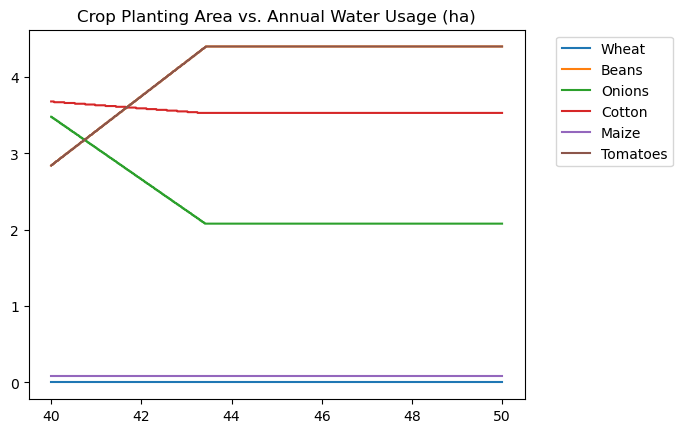

In [34]:
# 多次运行模型查看变化范围

cnt = 1001
x_range = [40 + i * 0.01 for i in range(cnt)]
solution = [[] for _ in range(num_crops)]
crop_name = ['Wheat', 'Beans', 'Onions', 'Cotton', 'Maize', 'Tomatoes']

model.setParam(COPT.Param.Logging, False)

for x in x_range:
    model.getConstrByName('water_year').ub = x
    model.solve()
    variables = model.getVars()
    for i in range(num_crops):
        solution[i].append(round(variables[i].x, 2))

for i in range(num_crops):
    plt.plot(x_range, solution[i], label=crop_name[i])
plt.legend(bbox_to_anchor=(1.05, 1))
plt.title('Crop Planting Area vs. Annual Water Usage (ha)')
plt.show()
    
# 恢复防止对后面产生影响
model.getConstrByName(f'water_year').ub = W

<font color=#B9C78D>
<b>提示：调整约束上界</b>
</font>   

在此处，由于我们需要多次调整某一参数的值，若每次重新建立模型将耗费大量的人力与计算资源，因此我们选择直接修改原有模型的约束条件。可以通过 `model.getConstrByName()` 函数根据约束名称找到对应的约束对象，再通过COPT属性 `ub` 来直接更改该约束的上界值。

## 案例拓展：调整总可用土地面积以观察解的变化趋势
将总可用土地面积由固定值 $10$ 改为在 $8$ 至 $12$ 范围内逐步调整，从而分析解随总可用土地面积变化而产生的影响。

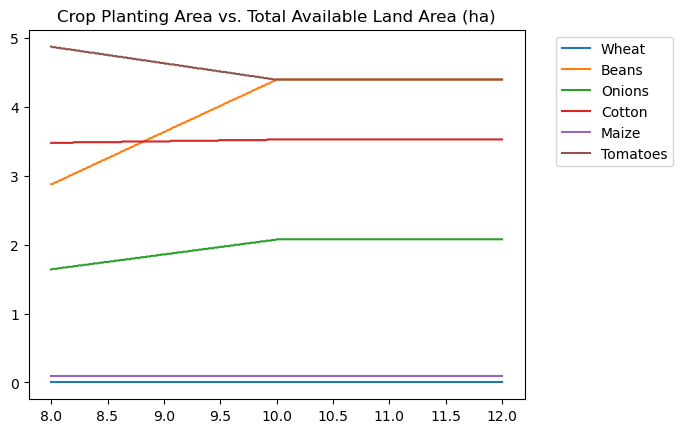

In [37]:
# 多次运行模型查看变化范围

cnt = 401
x_range = [8 + i * 0.01 for i in range(cnt)]
solution = [[] for _ in range(num_crops)]

model.setParam(COPT.Param.Logging, False)

for x in x_range:
    for i in range(12):
        model.getConstrByName(f'land({i})').ub = x
    model.solve()
    variables = model.getVars()
    for i in range(num_crops):
        solution[i].append(round(variables[i].x, 2))

for i in range(num_crops):
    plt.plot(x_range, solution[i], label=crop_name[i])
plt.legend(bbox_to_anchor=(1.05, 1))
plt.title('Crop Planting Area vs. Total Available Land Area (ha)')
plt.show()

# 恢复防止对后面产生影响
for i in range(12):
    model.getConstrByName(f'land({i})').ub = L